## Model to predict if a customer will subscribe to a term deposit or not




**Overview:**<br>
We are a small startup focusing mainly on providing machine learning solutions in the European banking market. We work on a variety of problems including fraud detection, sentiment classification and customer intention prediction and classification.<br>

We are interested in developing a robust machine learning system that leverages information coming from call center data.<br>

Ultimately, we are looking for ways to improve the success rate for calls made to customers for any product that our clients offer. Towards this goal we are working on designing an ever evolving machine learning product that offers high success outcomes while offering interpretability for our clients to make informed decisions.<br>

**Data Description:**<br>
The data comes from direct marketing efforts of a European banking institution. The marketing campaign involves making a phone call to a customer, often multiple times to ensure a product subscription, in this case a term deposit. Term deposits are usually short-term deposits with maturities ranging from one month to a few years. The customer must understand when buying a term deposit that they can withdraw their funds only after the term ends. All customer information that might reveal personal information is removed due to privacy concerns.

**Attributes:**<br>
age : age of customer (numeric)?<br>
job : type of job (categorical)<br>
marital : marital status (categorical)<br>
education (categorical)<br>
default: has credit in default? (binary)<br>
balance: average yearly balance, in euros (numeric)<br>
housing: has a housing loan? (binary)<br>
loan: has personal loan? (binary)<br>
contact: contact communication type (categorical)<br>
day: last contact day of the month (numeric)<br>
month: last contact month of year (categorical)<br>
duration: last contact duration, in seconds (numeric)<br>
campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)<br>
Output (desired target):<br>
y - has the client subscribed to a term deposit? (binary)


**Goal(s):**<br>
Predict if the customer will subscribe (yes/no) to a term deposit (variable y)
Success Metric(s): <br>

Hit %81 or above accuracy by evaluating with 5-fold cross validation and reporting the average performance score.<br>
Current Challenges:

We are also interested in finding customers who are more likely to buy the investment product. Determine the segment(s) of customers our client should prioritize.
What makes the customers buy? Tell us which feature we should be focusing more on.

In [1]:
#import warnings

#warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score


# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    RandomForestClassifier
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import RandomizedSearchCV

##Loading the data

In [2]:
# mount Google drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
pdata = pd.read_csv('/content/drive/MyDrive/MLProjects/CustomerSubscription/term-deposit-marketing-2020.csv')


In [4]:
data = pdata.copy()

## Overview of the data

In [6]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [7]:
data.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
39995,53,technician,married,tertiary,no,395,no,no,cellular,3,jun,107,1,no
39996,30,management,single,tertiary,no,3340,no,no,cellular,3,jun,238,3,yes
39997,54,admin,divorced,secondary,no,200,no,no,cellular,3,jun,170,1,yes
39998,34,management,married,tertiary,no,1047,no,no,cellular,3,jun,342,1,no
39999,38,technician,married,secondary,no,1442,yes,no,cellular,3,jun,113,1,no


In [8]:
data.shape

(40000, 14)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


In [10]:
data.duplicated().sum()

np.int64(0)

- No duplicates in the data

## Exploratory data analysis

In [11]:
data.describe()

,age,balance,day,duration,campaign
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,40.544600,1274.277550,16.017225,254.824300,2.882175
std,9.641776,2903.769716,8.278127,259.366498,3.239051
min,19.000000,-8019.000000,1.000000,0.000000,1.000000
25%,33.000000,54.000000,8.000000,100.000000,1.000000
50%,39.000000,407.000000,17.000000,175.000000,2.000000
75%,48.000000,1319.000000,21.000000,313.000000,3.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000


In [12]:
# Making a list of all categorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)


job
blue-collar      9383
management       8166
technician       6852
admin            4483
services         3910
retired          1437
self-employed    1414
entrepreneur     1405
unemployed       1104
housemaid        1087
student           524
unknown           235
Name: count, dtype: int64
--------------------------------------------------
marital
married     24386
single      10889
divorced     4725
Name: count, dtype: int64
--------------------------------------------------
education
secondary    20993
tertiary     11206
primary       6270
unknown       1531
Name: count, dtype: int64
--------------------------------------------------
default
no     39191
yes      809
Name: count, dtype: int64
--------------------------------------------------
housing
yes    24031
no     15969
Name: count, dtype: int64
--------------------------------------------------
loan
no     33070
yes     6930
Name: count, dtype: int64
--------------------------------------------------
contact
cellular     24

- job: This shows the distribution of job types among the customers. 'blue-collar', 'management', and 'technician' are the most frequent job categories, while 'student' and 'unknown' are the least frequent. The presence of 'unknown' indicates some missing or unclassified job information.

- marital: The majority of customers are 'married', followed by 'single', and then 'divorced'. This indicates a strong prevalence of married individuals in the dataset.

- education: 'secondary' education is the most common, followed by 'tertiary' and 'primary'. There's also an 'unknown' category for education, similar to 'job'.

- default: The vast majority of customers (39191) have 'no' credit in default, with a very small number (809) having 'yes'. This indicates a highly imbalanced distribution, which is important to consider for modeling.

- housing: More customers (24031) have a 'yes' for a housing loan compared to 'no' (15969).

- loan: The majority of customers (33070) do not have a personal loan ('no'), while a smaller group (6930) does ('yes').

- contact: 'cellular' is the most common contact type, followed by a significant number of 'unknown' contact types, and then 'telephone'. The 'unknown' contact type is a notable category.

- month: 'may' is by far the month with the most contacts, followed by 'jul' and 'aug'. 'dec', 'oct', and 'mar' have very few contacts, suggesting seasonality or specific campaign periods.

- y (target variable): This is the target variable indicating whether the client subscribed to a term deposit. A large majority of customers (37104) did 'no' subscribe, while a much smaller number (2896) did 'yes' subscribe. This shows a significant class imbalance, where the 'yes' class is the minority class. This imbalance is critical and will need to be addressed during model training to avoid biased predictions.

## Univariate analysis

In [5]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [14]:
# function to create labeled barplots

def labeled_barplot(data, feature, perc=False, n=None, hue=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    hue: column to use for color encoding (default is None)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)

    # Apply the fix for the FutureWarning
    if hue is None:
        ax = sns.countplot(
            data=data,
            x=feature,
            palette="Paired",
            order=data[feature].value_counts().index[:n].sort_values(),
            hue=feature, # Assign x variable to hue
            legend=False # Set legend to False
        )
    else:
        ax = sns.countplot(
            data=data,
            x=feature,
            palette="Paired",
            order=data[feature].value_counts().index[:n].sort_values(),
            hue=hue
        )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

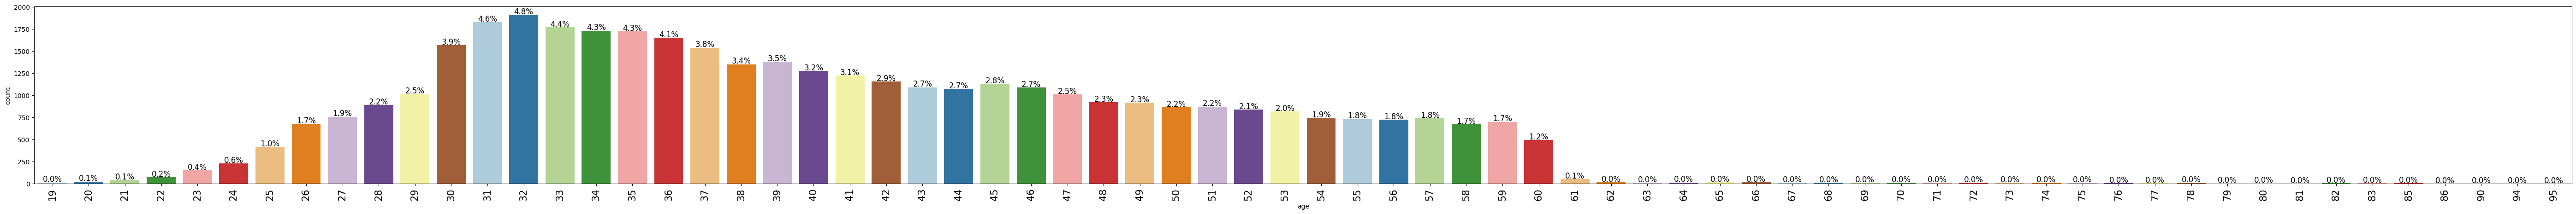

In [15]:
labeled_barplot(data, "age", perc=True)

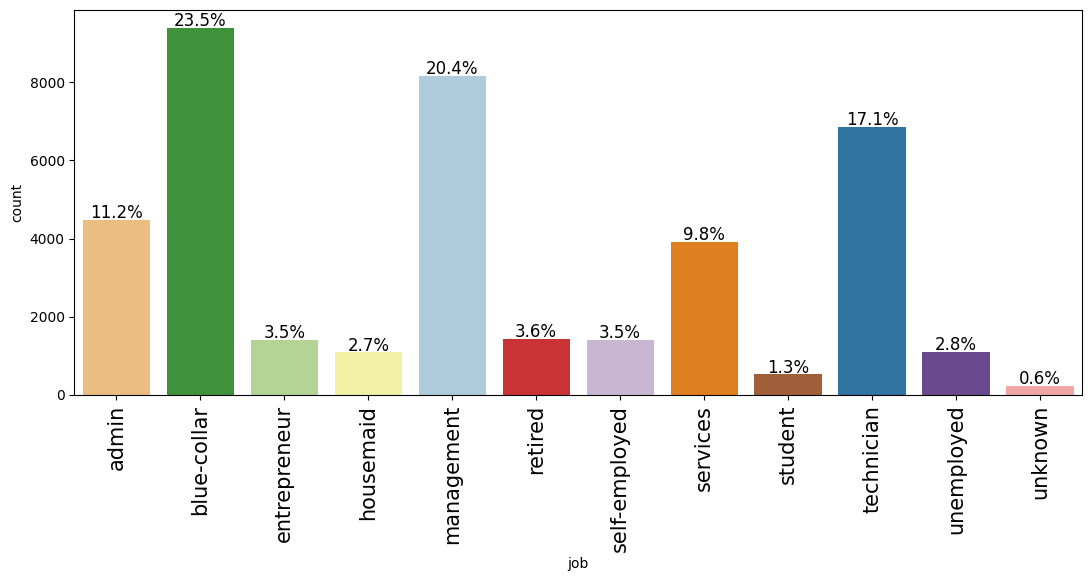

In [16]:
labeled_barplot(data, "job", perc=True)

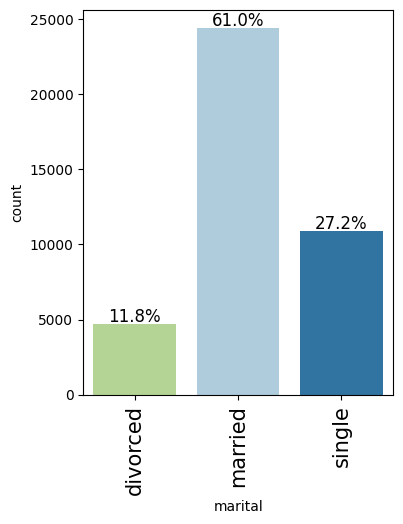

In [17]:
labeled_barplot(data, "marital", perc=True)

- Majority of the customers (61% )are married, 27.2% are single while 11.8% are divorced.

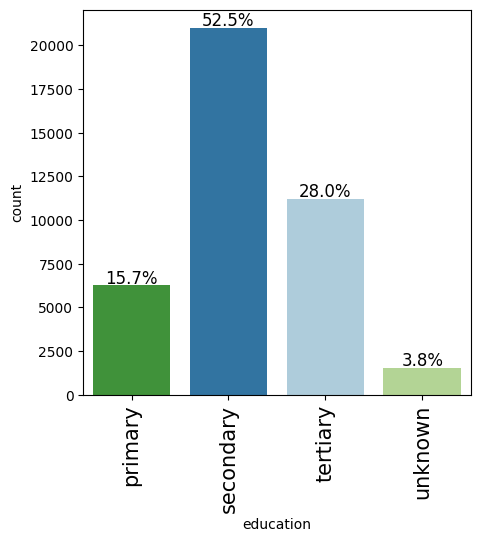

In [18]:
labeled_barplot(data, "education", perc=True)

- Majority (52.5%) have secondary education follwed by tertiary(28%), primary(15.7%) and unknown (3.8%)

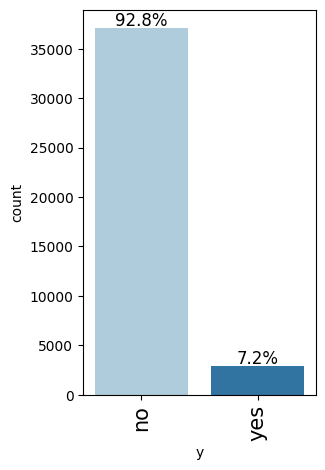

In [19]:
labeled_barplot(data, "y", perc=True)

- There is a significant class imbalance. Vast majority of customers (92.8%) did not subscribe to a term deposit.
- Only a small fraction (7.2%) subscribed to a term deposit

## Bivariate analysis

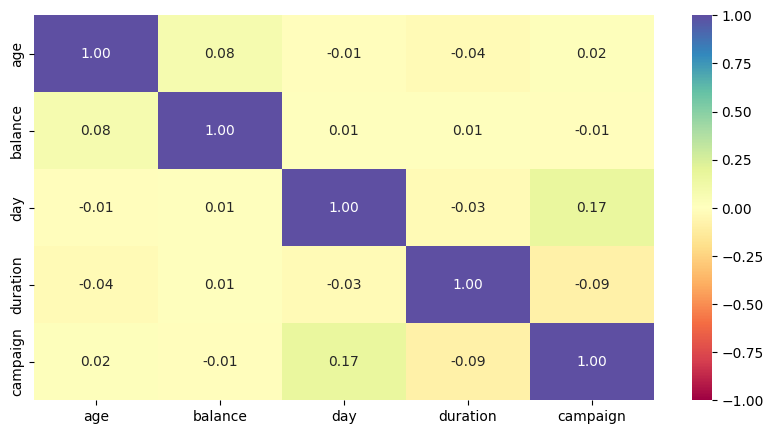

In [20]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

- The numerical variables appear to be largely uncorrelated with each other. This is a good finding for some modeling techniques as it suggests multicollinearity might not be a significant issue among these specific features.

In [21]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(
        data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow", hue=target, legend=False
    )  # Added hue=target and legend=False

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
        hue=target, legend=False # Added hue=target and legend=False
    )

    plt.tight_layout()
    plt.show()

In [22]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

y             no   yes    All
education                    
All        37104  2896  40000
secondary  19575  1418  20993
tertiary   10177  1029  11206
primary     5917   353   6270
unknown     1435    96   1531
------------------------------------------------------------------------------------------------------------------------


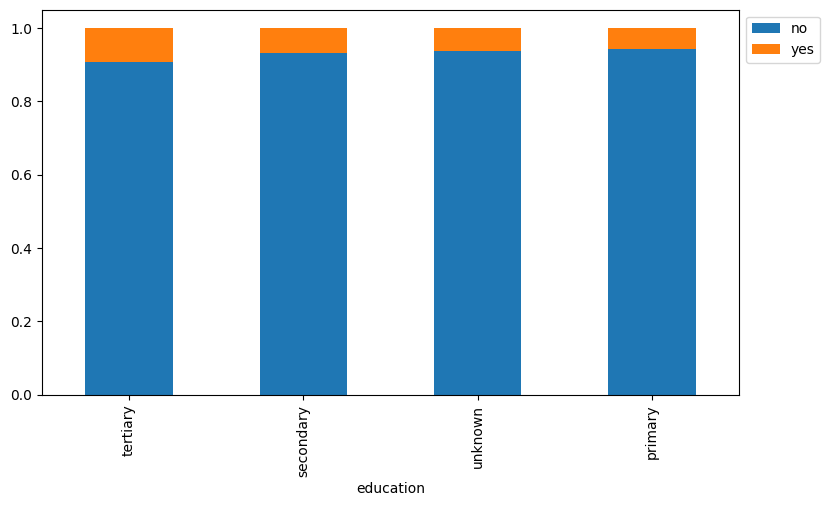

In [23]:
stacked_barplot(data, "education", "y")

- The education level of a customer does appear to be a differentiating factor in their likelihood to subscribe to a term deposit. Customers with tertiary education seem to be more receptive to the offering. This information can be valuable for targeted marketing strategies.

y            no   yes    All
campaign                    
All       37104  2896  40000
1         13454  1264  14718
2         10393   760  11153
3          4618   352   4970
4          3075   222   3297
5          1547    95   1642
6          1160    68   1228
7           664    35    699
8           501    25    526
9           299    19    318
11          184    13    197
10          250    12    262
13          125     6    131
17           63     6     69
12          150     4    154
15           79     4     83
14           89     4     93
16           76     2     78
21           34     1     35
24           19     1     20
20           42     1     43
32            8     1      9
29           15     1     16
18           51     0     51
22           23     0     23
25           22     0     22
23           22     0     22
27           10     0     10
26           13     0     13
28           16     0     16
30            8     0      8
31           12     0     12
19           4

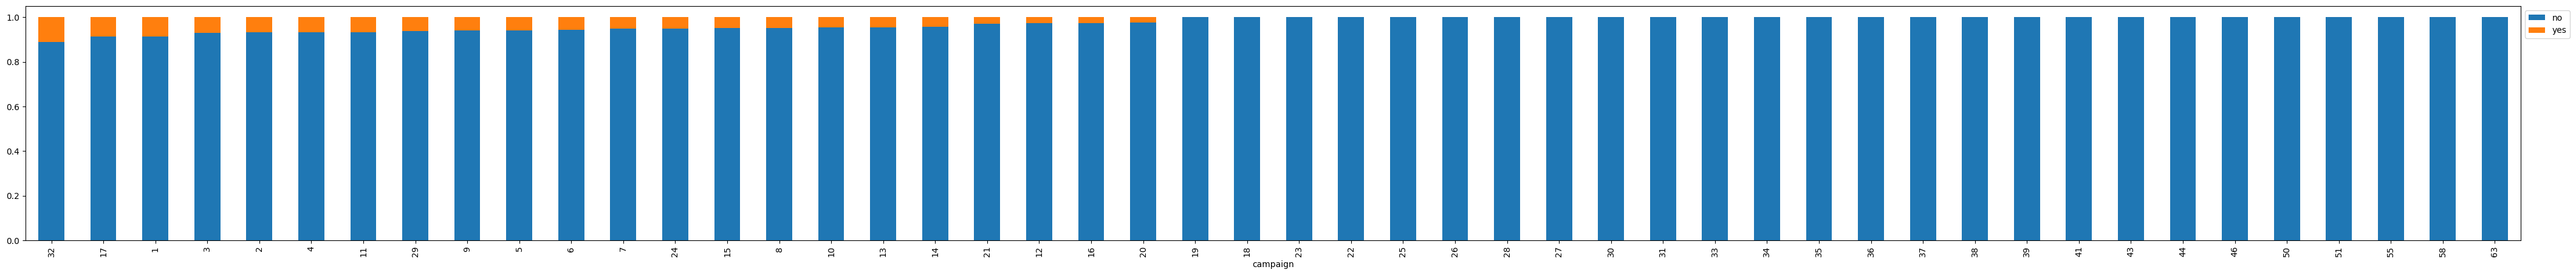

In [24]:
stacked_barplot(data, "campaign", "y")

- The data strongly suggests that there is a inverse relationship between number of contacts and the success rate of a subscription. Fewer, more targeted contacts are more effective in securing a term deposit subscription. Excessive contact attempts yield diminishing returns and lower success rates.



y       no   yes    All
day                    
All  37104  2896  40000
30    1233   224   1457
18    2008   165   2173
20    2502   153   2655
21    1775   139   1914
15    1345   123   1468
13    1208   117   1325
4     1066   117   1183
17    1697   115   1812
14    1521   115   1636
5     1578   113   1691
6     1668   110   1778
12    1185   104   1289
2     1005   104   1109
8     1518   102   1620
16    1119    96   1215
11    1187    85   1272
27     890    84    974
3      794    80    874
7     1532    80   1612
22     693    80    773
19    1577    73   1650
9     1302    72   1374
25     623    72    695
28    1589    61   1650
26     834    61    895
23     764    59    823
29    1551    49   1600
10     319    45    364
1      136    40    176
24     320    32    352
31     565    26    591
------------------------------------------------------------------------------------------------------------------------


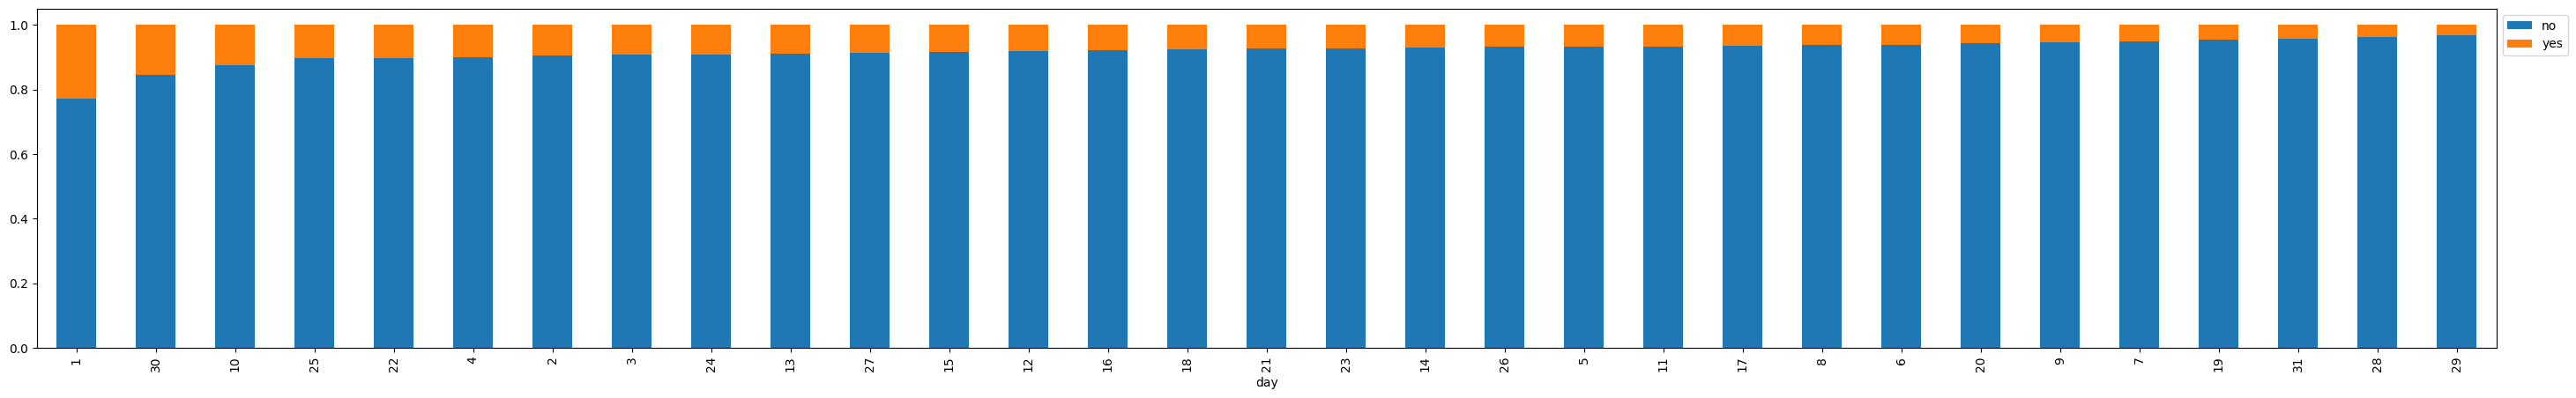

In [25]:
stacked_barplot(data, "day", "y")

- The data shows that there is no universally best day for contact.
- Imbalance Persists: Even on the most 'successful' days, the absolute number of 'yes' subscriptions is still much lower than 'no' subscriptions, reflecting the overall class imbalance in the dataset.

y         no   yes    All
month                    
All    37104  2896  40000
may    12741   791  13532
apr     2267   451   2718
jul     5996   384   6380
jun     4440   294   4734
aug     4927   288   5215
feb     2041   255   2296
nov     3378   220   3598
mar      133   125    258
oct       31    49     80
jan     1138    38   1176
dec       12     1     13
------------------------------------------------------------------------------------------------------------------------


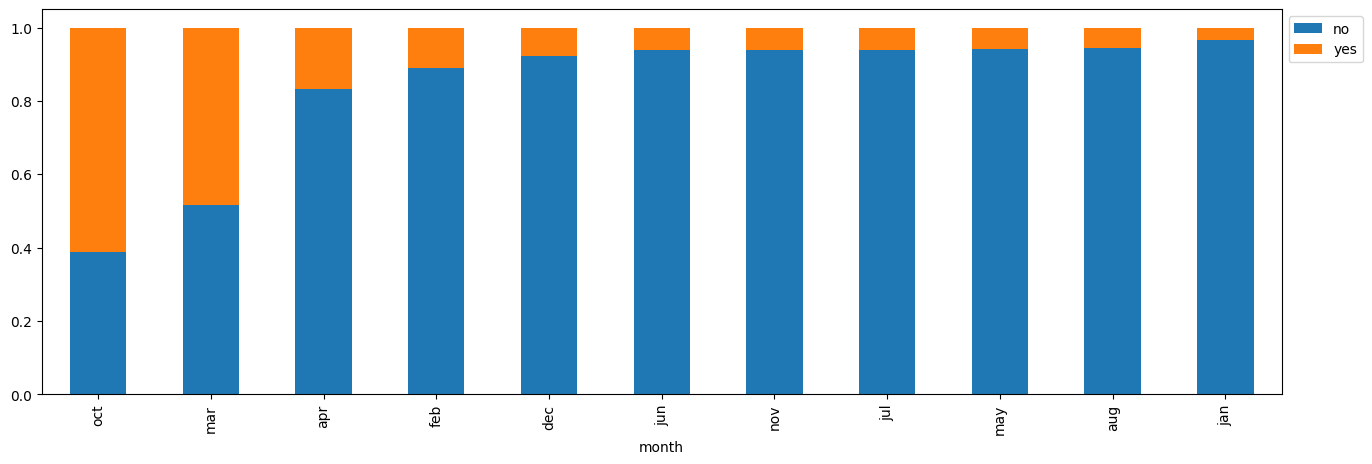

In [26]:
stacked_barplot(data, "month", "y")

- The plot clearly indicates a strong seasonal pattern in subscription success. Contacts made in certain months like **March and October** are far more effective in securing term deposit subscriptions, suggesting that customers might be more receptive during these periods. This could be influenced by seasonal financial planning, holidays, or specific marketing campaigns running during those times. Focusing marketing efforts on these high-success months, or analyzing why they are successful, could significantly improve overall campaign efficiency.
- High Contact Volume Months (May, July, August): These months show the highest number of contacts. However, despite the high volume, the proportion of 'yes' subscriptions is often lower compared to other months. For instance, May has the most contacts but not necessarily the highest success rate.

y           no   yes    All
default                    
All      37104  2896  40000
no       36344  2847  39191
yes        760    49    809
------------------------------------------------------------------------------------------------------------------------


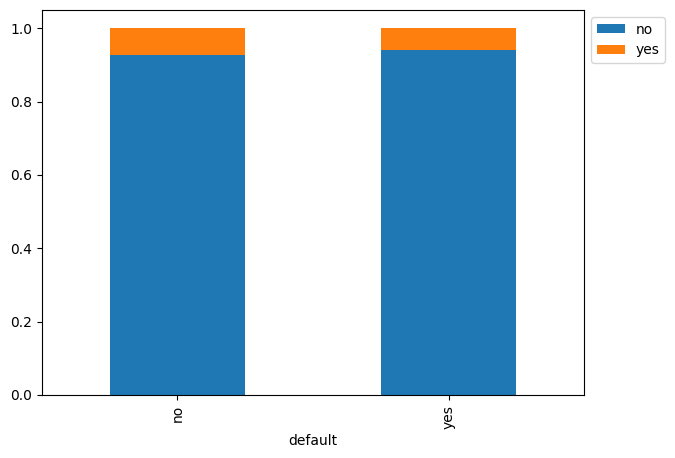

In [27]:
stacked_barplot(data, "default", "y")

- Vast Majority Without Default: The overwhelming majority of customers (39,191) do not have credit in default ('no'). Within this group, a small but significant number (2,847) subscribed to a term deposit.

- Small Number With Default: A very small fraction of customers (809) do have credit in default ('yes'). Out of these, an even smaller number (49) subscribed to a term deposit.

- Obersevation: Customers who do not have credit in default are significantly more likely to subscribe to a term deposit than those who do.

y           no   yes    All
housing                    
All      37104  2896  40000
yes      22567  1464  24031
no       14537  1432  15969
------------------------------------------------------------------------------------------------------------------------


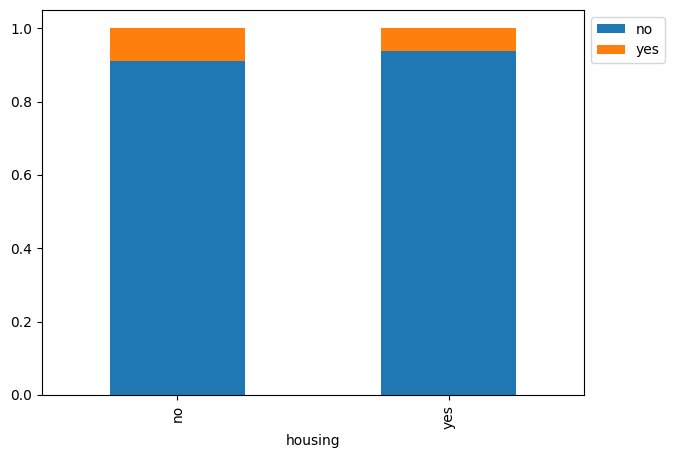

In [28]:
stacked_barplot(data, "housing", "y")

- Out of 24,031 customers with a housing loan, 1,464 (about 6.1%) subscribed to a term deposit.
- Out of 15,969 customers without a housing loan, 1,432 (about 8.9%) subscribed to a term deposit.
- This shows that customers without a housing loan have a slightly higher subscription rate proportionally, though the absolute numbers of subscribers in both groups are quite close.

y                 no   yes    All
job                              
All            37104  2896  40000
management      7490   676   8166
blue-collar     8848   535   9383
technician      6355   497   6852
admin           4132   351   4483
services        3672   238   3910
retired         1286   151   1437
self-employed   1302   112   1414
unemployed      1008    96   1104
entrepreneur    1317    88   1405
student          442    82    524
housemaid       1034    53   1087
unknown          218    17    235
------------------------------------------------------------------------------------------------------------------------


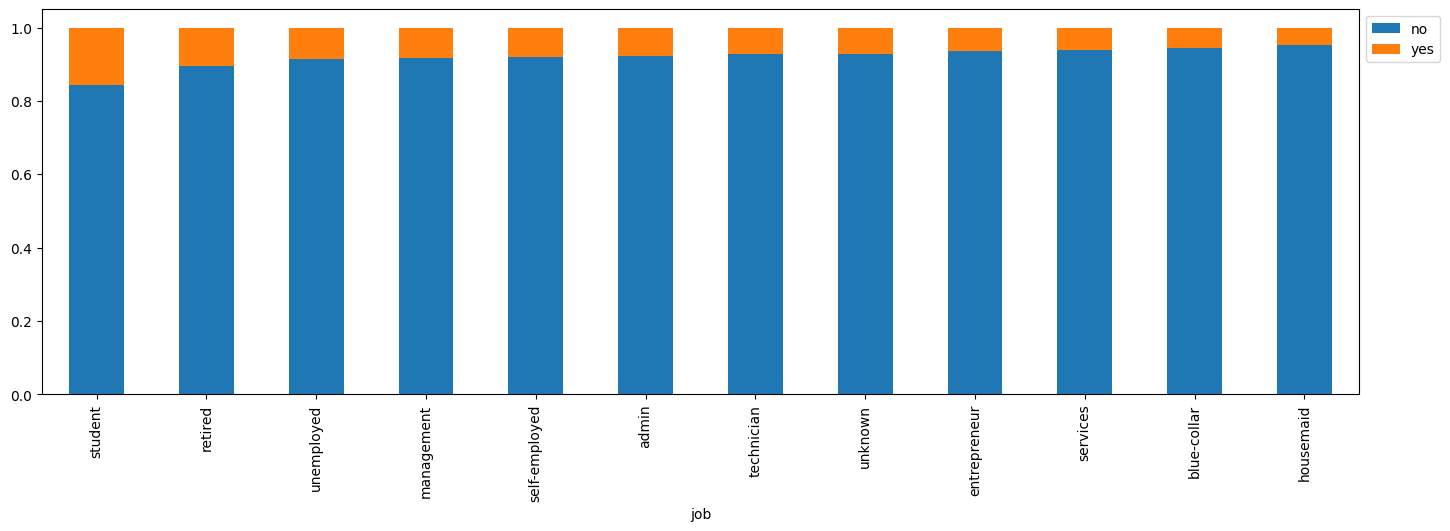

In [29]:
stacked_barplot(data, "job", "y")

- student and retired subscribe more than the rest of the job categories.
- Understanding why these groups are more inclined to subscribe could provide valuable insights for broader marketing strategies.

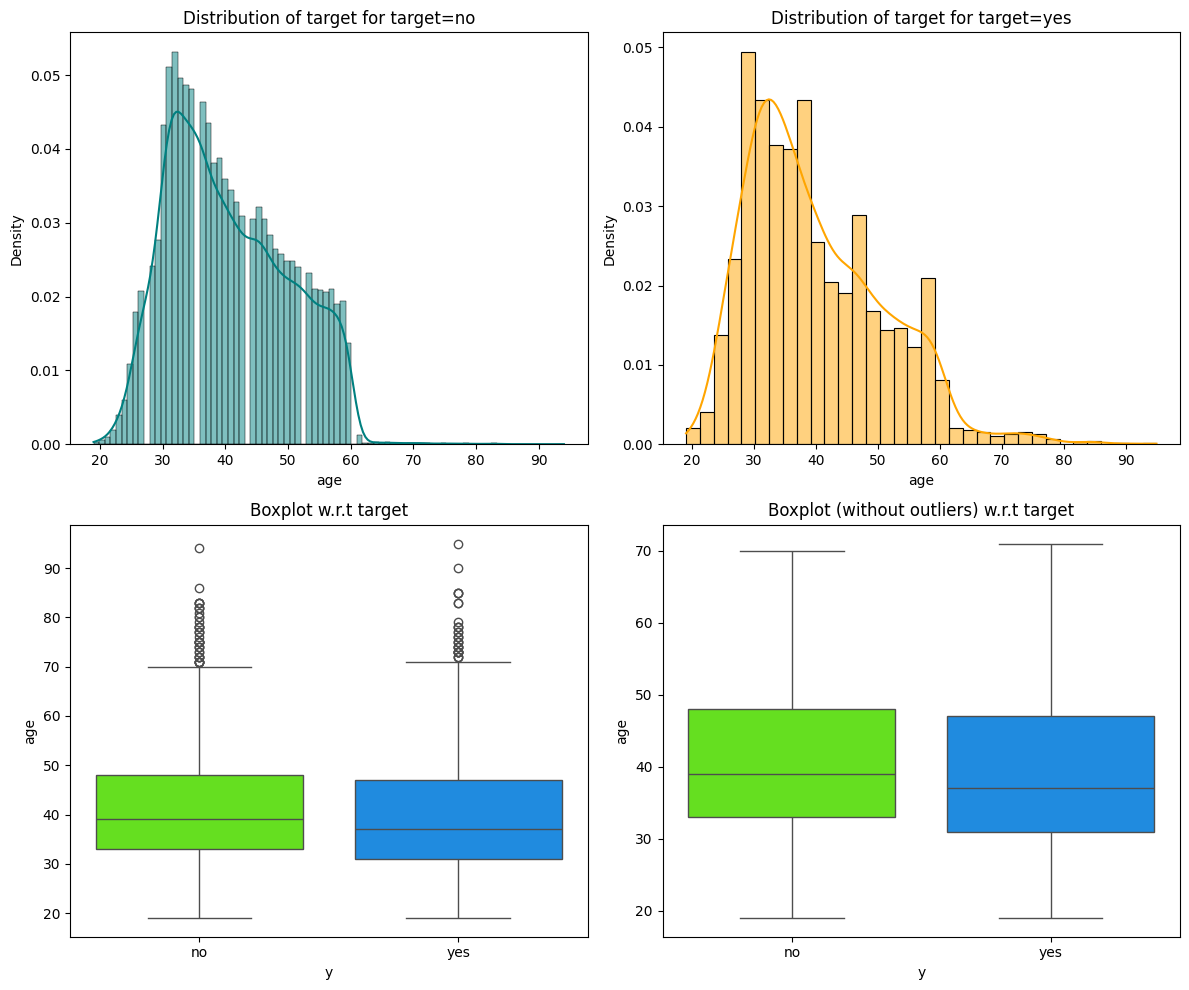

In [30]:
distribution_plot_wrt_target(data, "age", "y")

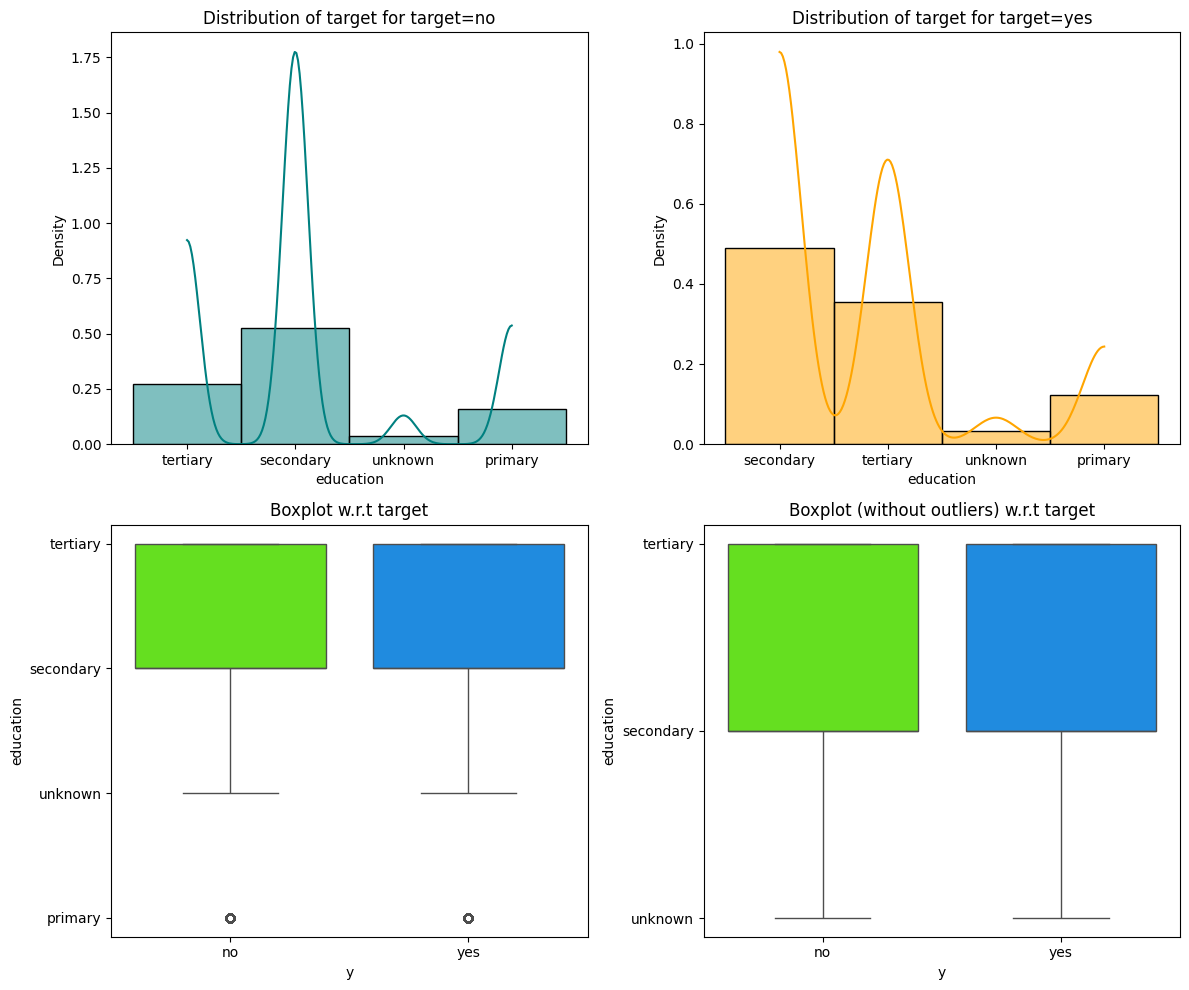

In [31]:
distribution_plot_wrt_target(data, "education", "y")

Overall, these plots visually confirm that a customer's education level plays a role in their likelihood of subscribing to a term deposit. You can typically see that customers with tertiary education tend to show a higher representation in the 'yes' subscription group compared to other education levels, making them a potentially more receptive target for marketing.

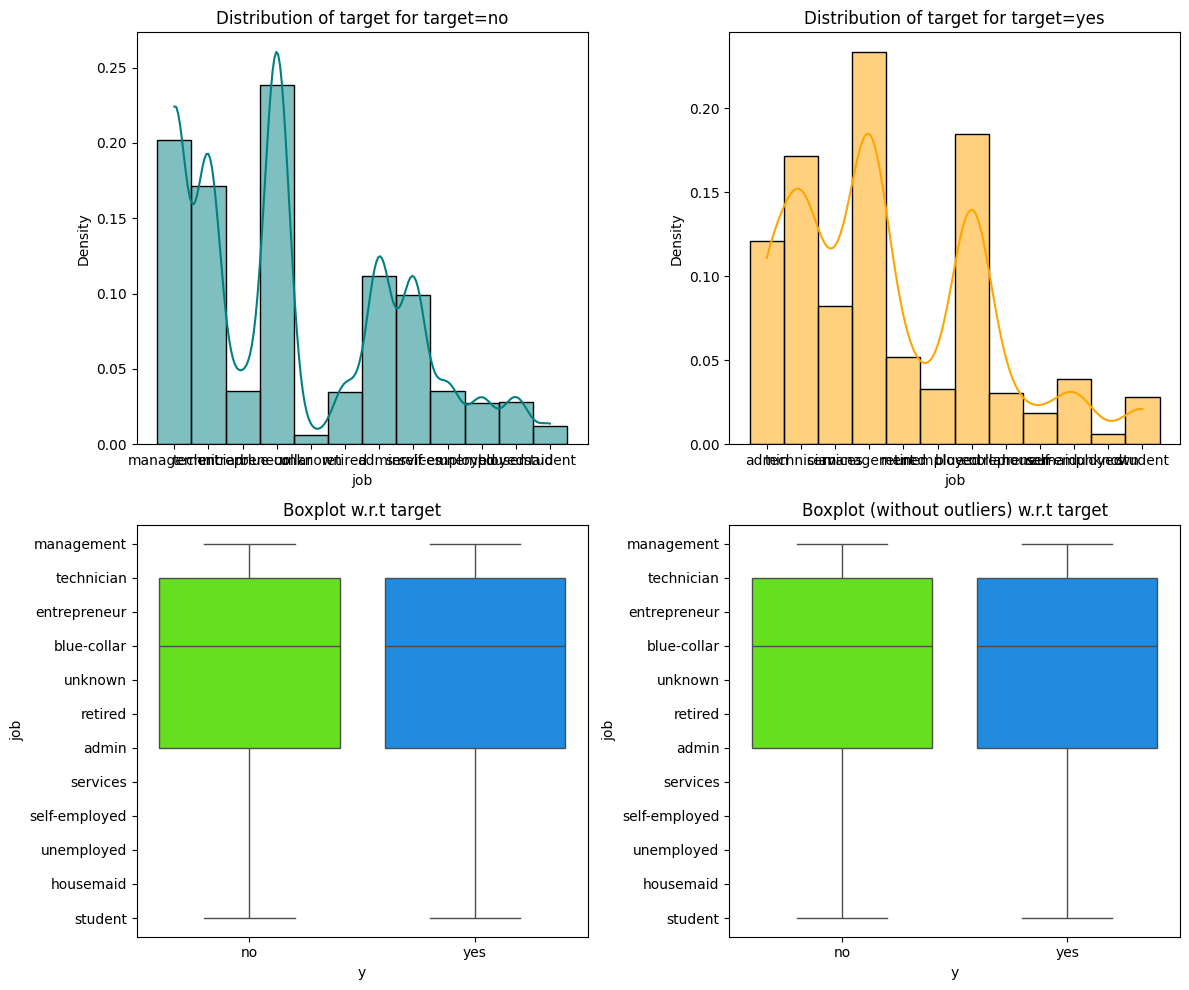

In [32]:
distribution_plot_wrt_target(data, "job", "y")

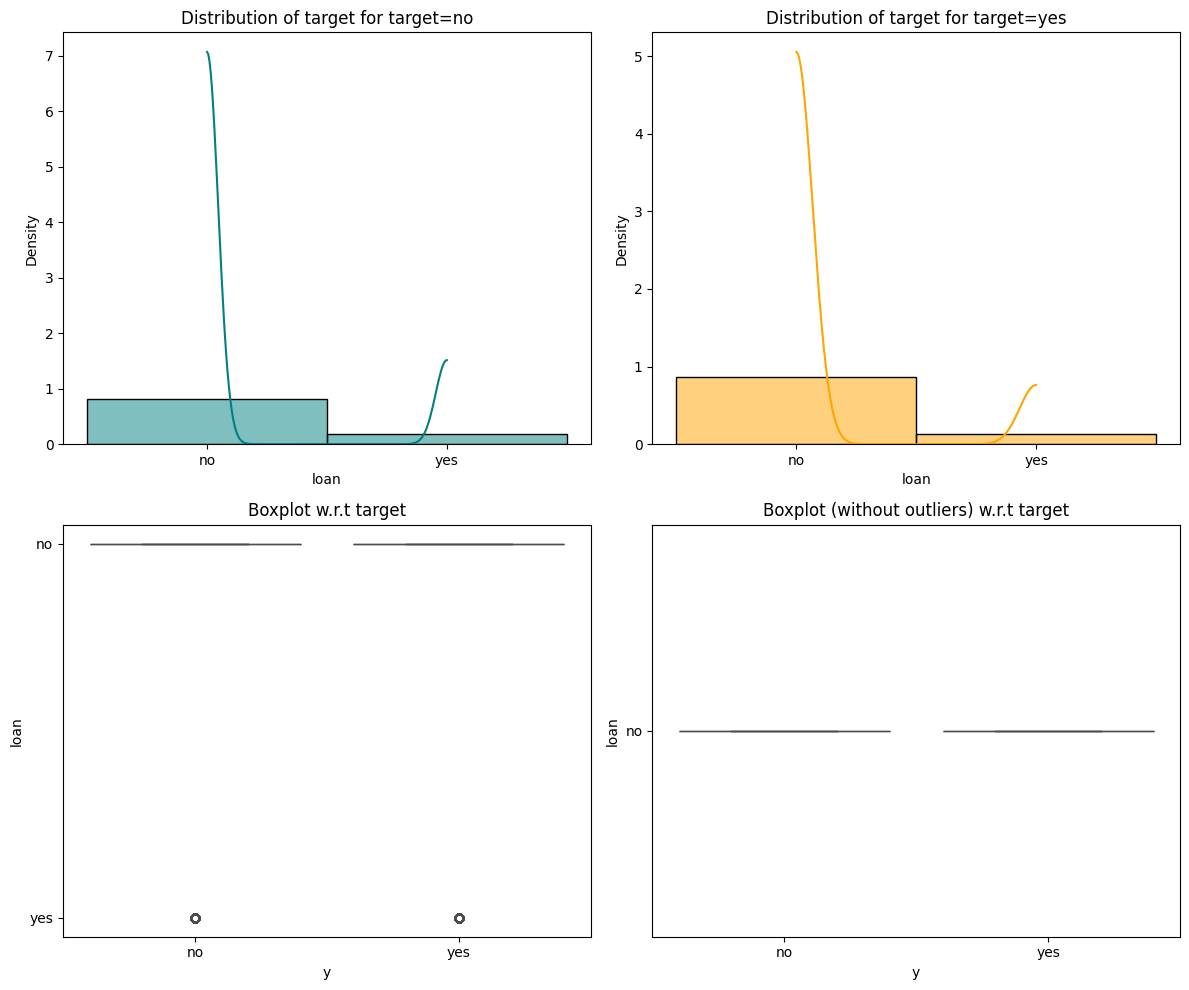

In [33]:
distribution_plot_wrt_target(data, "loan", "y")

- Customers who do not have a personal loan are generally more likely to subscribe to a term deposit. This suggests that having an existing financial commitment like a personal loan might reduce a customer's willingness or ability to invest in a term deposit.

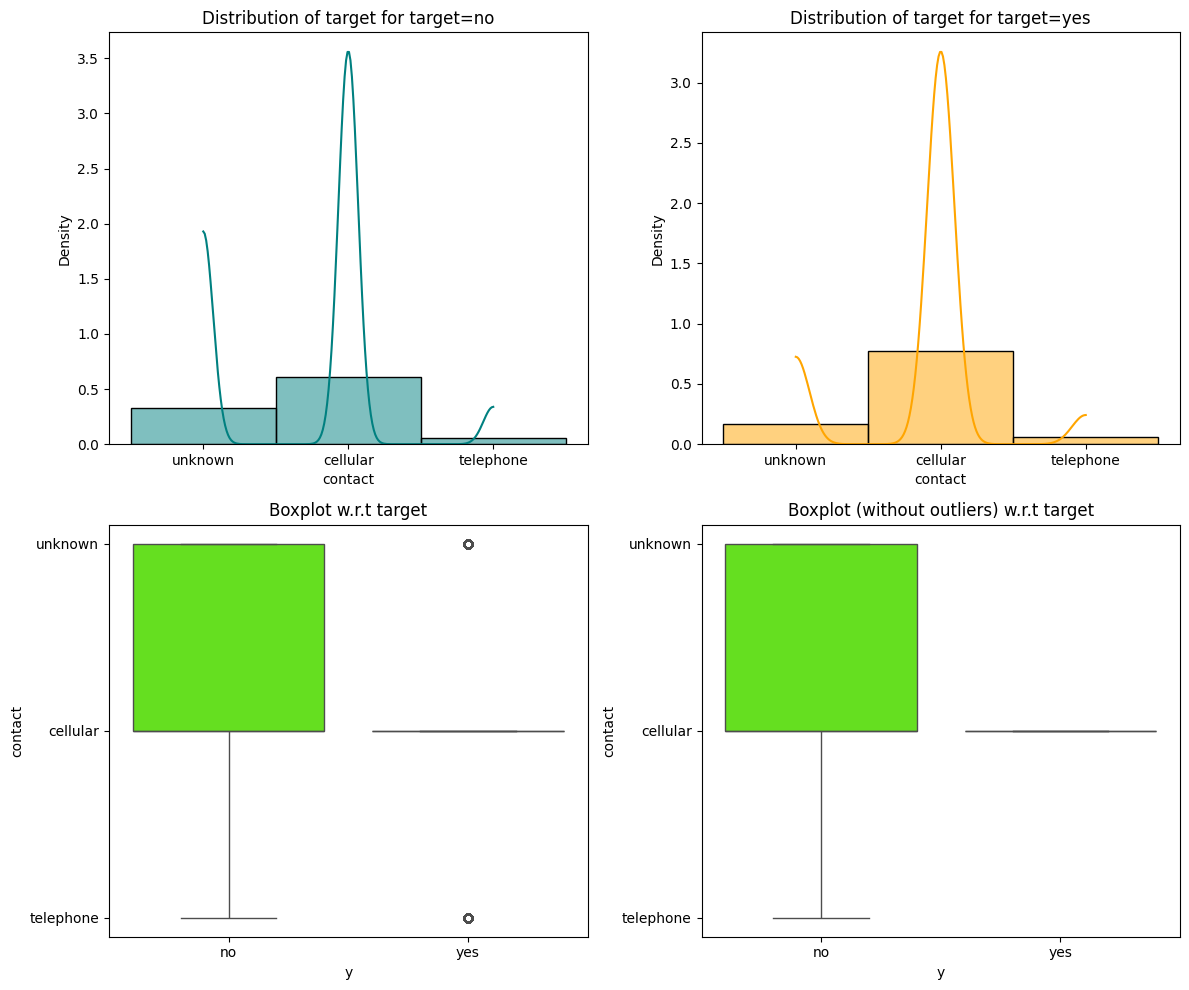

In [34]:
distribution_plot_wrt_target(data, "contact", "y")

- 'Cellular' contact appears to be the most effective channel for securing term deposit subscriptions. The 'unknown' contact type, while frequent, likely yields very few subscriptions, indicating a potential area for data improvement or a less effective segment for marketing efforts.

## Data preprocessing

###Outlier check

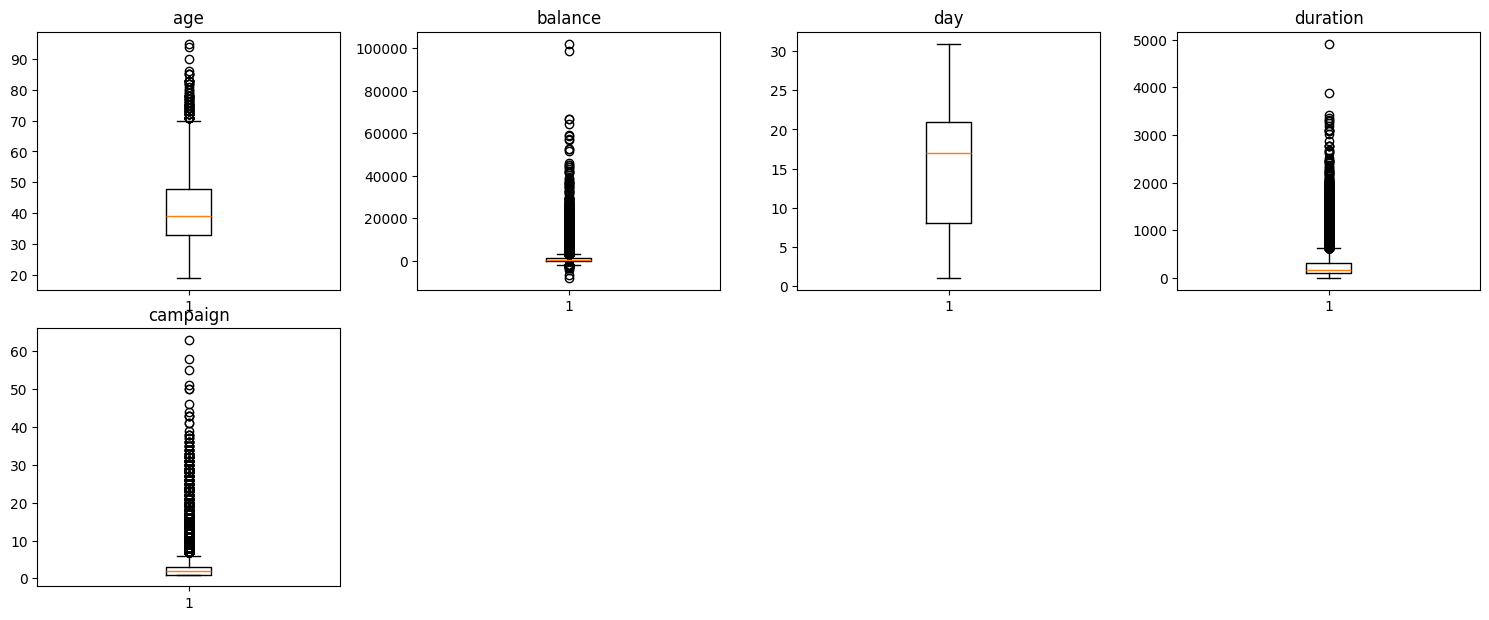

In [6]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

- balance', 'duration', and 'campaign' show prominent outliers, primarily on the higher end, suggesting extreme values for these features. 'age' also has some outliers, representing older customers. These outliers need to be considered carefully during feature engineering and model training, as they can significantly impact model performance, especially for algorithms sensitive to extreme values.



### Data preparation for modelling

In [7]:
data["y"] = data["y"].apply(lambda x: 1 if x == "yes" else 0)

X = data.drop(["y"], axis=1)
y = data["y"]


X = pd.get_dummies(X, drop_first=True)

# Splitting data into training and validation set:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)

#Test data
X_val,X_test,y_val,y_test = train_test_split(
    X_val,y_val,test_size=0.1,random_state=1,stratify=y_val
)


In [37]:
print("Shape of Training set : ", X_train.shape)
print("Shape of Validation set : ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (28000, 36)
Shape of Validation set :  (10800, 36)
Shape of test set :  (1200, 36)
Percentage of classes in training set:
y
0    0.927607
1    0.072393
Name: proportion, dtype: float64
Percentage of classes in validation set:
y
0    0.927593
1    0.072407
Name: proportion, dtype: float64
Percentage of classes in test set:
y
0    0.9275
1    0.0725
Name: proportion, dtype: float64


### Model evaluation criteria

**Model can make wrong predictions as:**
- Customer is predicted to subscribe but in reality does not
- Customer is predicted not to subscribe but in reality does

** Which case is more important**
Both:
- If a customer is prediced to subscribe but does not, marketing efforts are wasted on them.
-If a customer is predicted not to subscribe but does, a potential customer could have been missed.

**How to reduce losses**
- FI score is a better balanced metic especially since the classes are inbalanced.

In [8]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [9]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Defining scorer to be used for cross-validation and hyperparameter tuning

In [10]:
scorer = metrics.make_scorer(metrics.f1_score)

In [11]:
models = []  # Empty list to store all the models

# Appending models into the list

models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
models.append(("Logistic Regression", LogisticRegression(random_state=1, solver='liblinear')))
models.append(("KNN", KNeighborsClassifier()))
models.append(("SVM", SVC(random_state=1, probability=True)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring = scorer,cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Random forest: 0.41975904039075634
Xgboost: 0.4956826490408203
dtree: 0.4140951989411922
Logistic Regression: 0.3796299501152364
KNN: 0.3440080015588144
SVM: 0.04741399409651144

Validation Performance:

Random forest: 0.3895004233700254
Xgboost: 0.4654919236417034
dtree: 0.41253918495297803
Logistic Regression: 0.36187113857016767
KNN: 0.30272108843537415
SVM: 0.04141291108404385


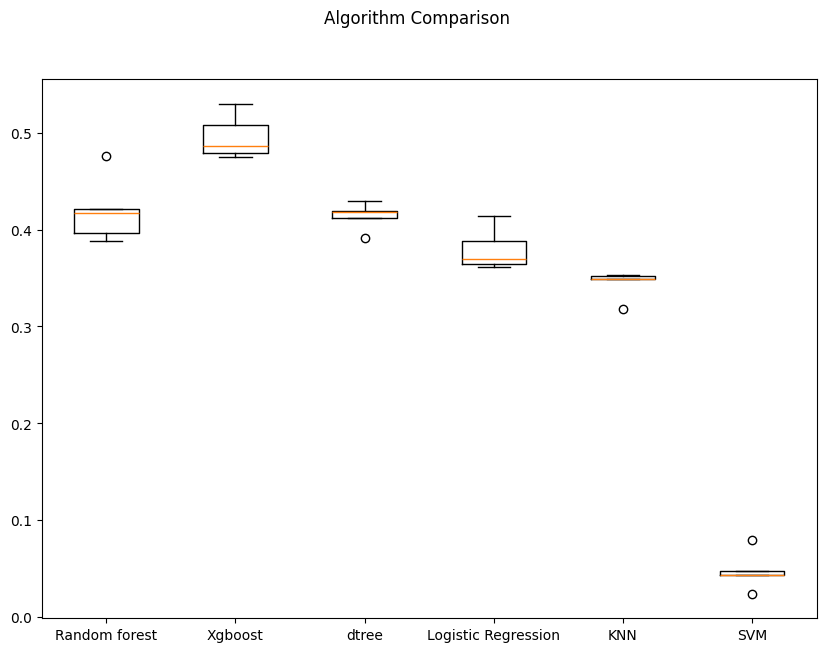

In [44]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

- **XGBoost** stands out with the highest median F1-score and a relatively tight box, indicating both strong average performance and good consistency across the 5 cross-validation folds.
- **Random Forest** follows closely behind, also showing good performance and consistency, though slightly lower than XGBoost.
- **Decision Tree** has a respectable F1-score but might show a bit more variability in its performance compared to the ensemble methods.
- **Logistic Regression and KNN** are in the middle of the pack, with lower F1-scores and potentially wider boxes, suggesting less consistent performance.
- **SVM** is clearly the weakest performer, with a very low median F1-score and possibly a very narrow box (or even just a line if all its CV scores were very similar and low). This confirms that SVM, with its current parameters, is not performing well on this imbalanced dataset.

## Model building with SMOTE oversampling

In [48]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After OverSampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, counts of label '0': {} \n".format(sum(y_train_over == 0)))


print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, counts of label '1': 2027
Before OverSampling, counts of label '0': 25973 

After OverSampling, counts of label '1': 25973
After OverSampling, counts of label '0': 25973 

After OverSampling, the shape of train_X: (51946, 36)
After OverSampling, the shape of train_y: (51946,) 



In [50]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))
#models.append(("Logistic Regression", LogisticRegression(random_state=1, solver='liblinear')))
#models.append(("KNN", KNeighborsClassifier()))
#models.append(("SVM", SVC(random_state=1, probability=True)))


results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over,scoring = scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Random forest: 0.963955544783035
Xgboost: 0.9614805712591391
dtree: 0.947195406200397

Validation Performance:

Random forest: 0.456490727532097
Xgboost: 0.48854961832061067
dtree: 0.42220936957779065


# Feature scaling of numerical columns

In [51]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to be scaled
# These columns were identified in previous EDA as 'age', 'balance', 'day', 'duration', 'campaign'
numerical_cols_to_scale = ['age', 'balance', 'day', 'duration', 'campaign']

print("Numerical columns identified for scaling:", numerical_cols_to_scale)

Numerical columns identified for scaling: ['age', 'balance', 'day', 'duration', 'campaign']


In [52]:
scaler = StandardScaler()

# Fit on X_train_over numerical columns
X_train_over[numerical_cols_to_scale] = scaler.fit_transform(X_train_over[numerical_cols_to_scale])

# Transform X_val and X_test numerical columns using the same fitted scaler
X_val[numerical_cols_to_scale] = scaler.transform(X_val[numerical_cols_to_scale])
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Shape of Training set after scaling: ", X_train_over.shape)
print("Shape of Validation set after scaling: ", X_val.shape)
print("Shape of test set after scaling: ", X_test.shape)

print("\nDescriptive statistics for scaled numerical columns in X_train_over:")
print(X_train_over[numerical_cols_to_scale].describe())

Shape of Training set after scaling:  (51946, 36)
Shape of Validation set after scaling:  (10800, 36)
Shape of test set after scaling:  (1200, 36)

Descriptive statistics for scaled numerical columns in X_train_over:
                age       balance           day      duration      campaign
count  5.194600e+04  5.194600e+04  5.194600e+04  5.194600e+04  5.194600e+04
mean   3.819034e-16  9.848511e-18 -5.909107e-17  6.127963e-17 -2.188558e-17
std    1.000010e+00  1.000010e+00  1.000010e+00  1.000010e+00  1.000010e+00
min   -2.229270e+00 -3.223454e+00 -1.901148e+00 -1.100525e+00 -5.574054e-01
25%   -7.390383e-01 -4.618305e-01 -8.602360e-01 -7.433025e-01 -5.574054e-01
50%   -2.068125e-01 -3.180953e-01  5.056175e-02 -3.498746e-01 -1.821124e-01
75%    6.447487e-01  5.657001e-02  7.011316e-01  5.093912e-01  1.931806e-01
max    5.860561e+00  3.302916e+01  2.002271e+00  1.076989e+01  2.271076e+01


## Train Models with Scaled Data


In [53]:
models_scaled = []  # Empty list to store all the scaled models

# Appending models into the list
models_scaled.append(("Random forest", RandomForestClassifier(random_state=1)))
models_scaled.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models_scaled.append(("dtree", DecisionTreeClassifier(random_state=1)))

results_scaled = []  # Empty list to store all model's CV scores
names_scaled = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset with scaled data:" "\n")

for name, model in models_scaled:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring = scorer,cv=kfold
    )
    results_scaled.append(cv_result)
    names_scaled.append(name)
    print("{}: {}".format(name, cv_result.mean()))



Cross-Validation performance on training dataset with scaled data:

Random forest: 0.9639894595416754
Xgboost: 0.9614805712591391
dtree: 0.947287604909644


In [54]:
#evaluate their performance on the scaled validation set.
print("\n" "Validation Performance with scaled data:" "\n")

for name, model in models_scaled:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Validation Performance with scaled data:

Random forest: 0.45803698435277385
Xgboost: 0.48854961832061067
dtree: 0.42427745664739885


### Evaluate Model Performance with Scaled Data

In [55]:
from sklearn.metrics import roc_auc_score


Model Performance on Scaled Validation Set:

========== Random forest ==========
   Accuracy    Recall  Precision        F1
0  0.929444  0.411765   0.516026  0.458037


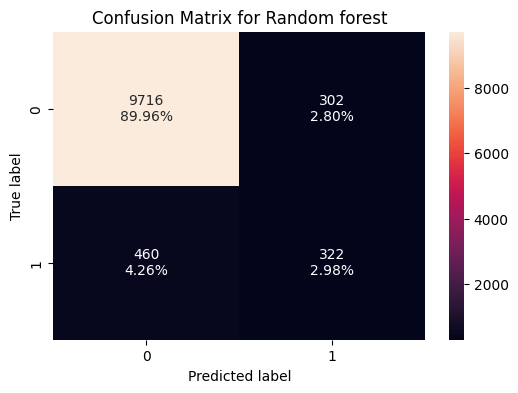

AUC Score: 0.9333

========== Xgboost ==========
   Accuracy    Recall  Precision       F1
0  0.925556  0.491049   0.486076  0.48855


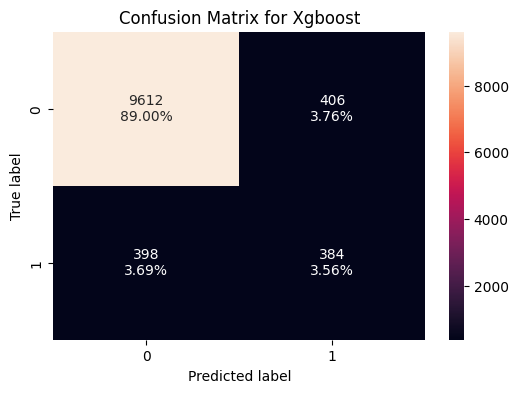

AUC Score: 0.9306

========== dtree ==========
   Accuracy    Recall  Precision        F1
0  0.907778  0.469309   0.387131  0.424277


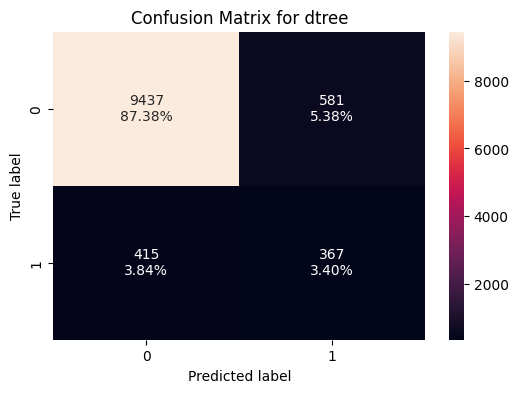

AUC Score: 0.7057



In [56]:
print("\nModel Performance on Scaled Validation Set:\n")

for name, model in models_scaled:
    print(f"========== {name} ==========")

    # Make predictions on the scaled validation set
    y_pred_val = model.predict(X_val)

    # Print classification metrics
    perf_df = model_performance_classification_sklearn(model, X_val, y_val)
    print(perf_df)

    # Display confusion matrix
    confusion_matrix_sklearn(model, X_val, y_val)
    plt.title(f"Confusion Matrix for {name}")
    plt.show()

    # Calculate and print AUC score
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    auc_score = roc_auc_score(y_val, y_pred_proba)
    print(f"AUC Score: {auc_score:.4f}\n")


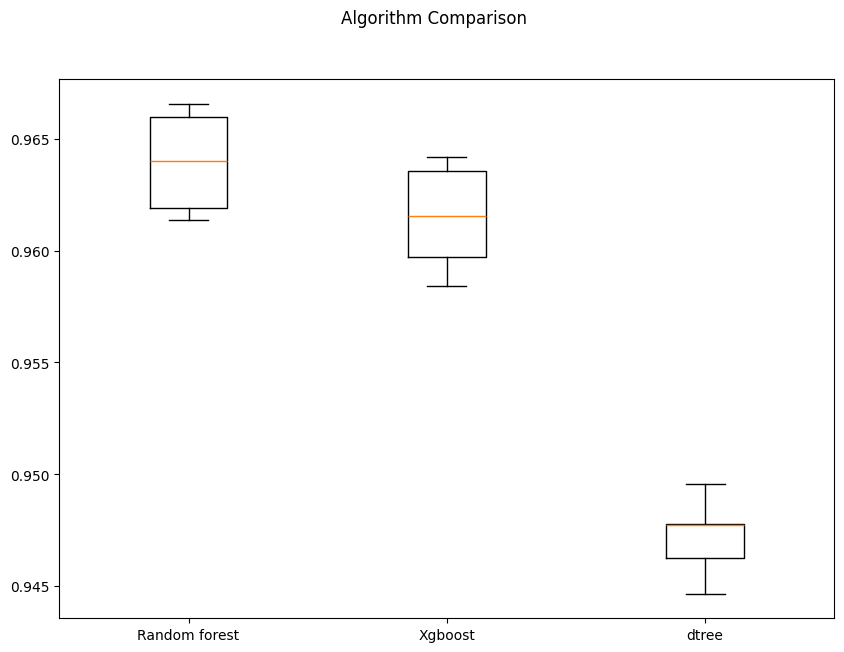

In [57]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()


-The boxplot visually confirms what the printed cross-validation scores also indicated:
- **Overfitting Indication:** There's a significant drop in F1-score from the cross-validation performance on the oversampled training data (which were all above 0.94) to the performance on the validation set (all below 0.5). This strongly suggests that all three models, despite SMOTE oversampling, are overfitting to the training data. They perform very well on data they've seen (or synthesized variations of), but generalize less effectively to truly unseen data.
- **XGBoost** appears to be the best-performing model among the three, offering both a higher average F1-score and likely more consistent performance. <br>
- **Random Forest** is a strong second, while the basic Decision Tree lags behind. The F1-score was chosen as the evaluation metric, which is particularly important for imbalanced datasets like ours, where accuracy alone can be misleading.


### Insights or Next Steps

*   The significant drop in F1-score from cross-validation on the training set to evaluation on the validation set suggests potential overfitting to the oversampled training data. Techniques like hyperparameter tuning with a focus on regularization or using different sampling strategies might be beneficial.
*   Given the high AUC scores but moderate F1-scores, particularly for XGBoost and Random Forest, further optimization could involve fine-tuning class weight parameters or adjusting the classification threshold to improve recall and precision balance for the minority class, depending on the business objective.


# Tuning Random Forest with undersampled data

#Undersampling

In [58]:
print("Before UnderSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before UnderSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

# Random Under Sampling
rus = RandomUnderSampler(sampling_strategy=1, random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)


print("After UnderSampling, counts of label '1': {}".format(sum(y_train_un == 1)))
print("After UnderSampling, counts of label '0': {} \n".format(sum(y_train_un == 0)))


print("After UnderSampling, the shape of X_train_un: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of y_train_un: {} \n".format(y_train_un.shape))

Before UnderSampling, counts of label '1': 2027
Before UnderSampling, counts of label '0': 25973 

After UnderSampling, counts of label '1': 2027
After UnderSampling, counts of label '0': 2027 

After UnderSampling, the shape of X_train_un: (4054, 36)
After UnderSampling, the shape of y_train_un: (4054,) 



In [59]:
%%time

# defining model
Model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [0.3, 0.4, 0.5, 'sqrt'], # Corrected to pass individual float values or 'sqrt'
    "max_samples": np.arange(0.4, 0.7, 0.1)}


#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 200, 'min_samples_leaf': np.int64(1), 'max_samples': np.float64(0.5), 'max_features': 0.4} with CV score=0.8981298338958071:
CPU times: user 2.31 s, sys: 169 ms, total: 2.48 s
Wall time: 3min 52s


In [60]:
# Creating new pipeline with best parameters
tuned_rf2 = RandomForestClassifier(
    n_estimators=randomized_cv.best_params_['n_estimators'],
    min_samples_leaf=randomized_cv.best_params_['min_samples_leaf'],
    max_samples=randomized_cv.best_params_['max_samples'],
    max_features=randomized_cv.best_params_['max_features'],
    random_state=1
)

tuned_rf2.fit(X_train_un, y_train_un)

RandomForestClassifier(max_features=0.4, max_samples=np.float64(0.5),
                       min_samples_leaf=np.int64(1), n_estimators=200,
                       random_state=1)

In [61]:
rf2_train_perf = model_performance_classification_sklearn(
    tuned_rf2, X_train_un, y_train_un
)
rf2_train_perf

,Accuracy,Recall,Precision,F1
0,0.9704,0.983226,0.958634,0.970774


In [62]:
rf2_val_perf = model_performance_classification_sklearn(tuned_rf2, X_val, y_val)
rf2_val_perf

,Accuracy,Recall,Precision,F1
0,0.927778,0.007673,0.6,0.015152


- Training the Random Forest model on undersampled data has resulted in extremely poor performance in identifying customers who will subscribe to a term deposit. It appears the model learned very little about the minority class, likely because undersampling removes a significant amount of potentially valuable information from the majority class, making it harder for the model to distinguish between the two classes effectively.

- Conversely, SMOTE oversampling led to a much better, though still moderate, performance on the validation set, especially in terms of recall and F1-score, indicating it was more successful in helping the model learn from the minority class. Based on these results, undersampling is not a suitable strategy for this dataset with the current Random Forest setup

## Hyperparameter Tuning for XGBoost using RandomizedSearchCV

In [65]:
%%time


# defining model
Model = XGBClassifier(random_state=1,eval_metric='logloss')

#Parameter grid to pass in RandomSearchCV
param_grid={'n_estimators':[150,200,250],'scale_pos_weight':[5,10], 'learning_rate':[0.1,0.2], 'gamma':[0,3,5], 'subsample':[0.8,0.9]}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)## Complete the code to fit the model on over sampled data

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'scale_pos_weight': 5, 'n_estimators': 250, 'learning_rate': 0.2, 'gamma': 0} with CV score=0.9404660670015008:
CPU times: user 4.69 s, sys: 391 ms, total: 5.08 s
Wall time: 4min 4s


In [67]:
xgb2 = XGBClassifier(
    random_state=1,
    eval_metric="logloss",
    subsample=0.8,
    scale_pos_weight=10,
    n_estimators=250,
    learning_rate=0.2,
    gamma=0,
)

xgb2.fit(X_train_over, y_train_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=None,
              num_parallel_tree=None, ...)

In [68]:
xgb2_train_perf = model_performance_classification_sklearn(
    xgb2, X_train_over, y_train_over
)
xgb2_train_perf

,Accuracy,Recall,Precision,F1
0,0.982578,1.0,0.966329,0.982876


In [69]:
xgb2_val_perf = model_performance_classification_sklearn(xgb2, X_val, y_val)
xgb2_val_perf

,Accuracy,Recall,Precision,F1
0,0.91,0.668798,0.423139,0.518335


- The model has an accuracy of 91% on the validation set, which meets the 81% target. However, as noted, accuracy is not the primary metric for imbalanced data. The cross-validation F1-score on the training data was around 0.94, but the validation F1-score is 0.518, which highlights the overfitting challenge previously discussed.

- In summary, the tuned XGBoost model shows a good ability to identify actual subscribers (high recall) but still has room for improvement in its precision. The F1-score of 0.518 is an improvement, but the gap between training and validation performance indicates that further fine-tuning or more advanced techniques might be needed to improve generalization and optimize the balance between precision and recall for the specific business needs.